<a href="https://colab.research.google.com/github/Susan-fox/PS2-Adaptive-Ticket-Auctions/blob/main/auction_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


AI-Assisted Ticket Allocation Simulation
Random seed: 2026
Simulations per condition: 500
Genuine fans: 200
Scalpers: 50
Tickets: 100

Mean outcomes:
       mechanism    ai  genuine_fan_allocation_rate  scalper_allocation_rate  social_welfare  scalper_profit
            FCFS    AI                        0.639                    0.361       11877.013        2817.048
            FCFS No AI                        0.758                    0.242       13118.795        1573.000
Randomized Queue    AI                        0.798                    0.202       14880.354        1577.940
Randomized Queue No AI                        0.800                    0.200       13921.416        1299.740

Effect of AI within each mechanism
       mechanism  change_in_fan_allocation_with_AI  change_in_scalper_allocation_with_AI
            FCFS                            -0.119                                 0.119
Randomized Queue                            -0.002                                 0.002



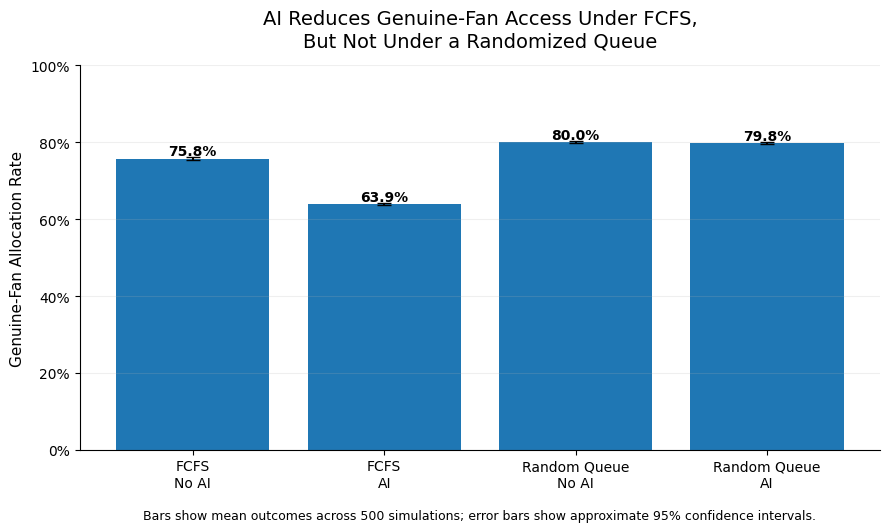

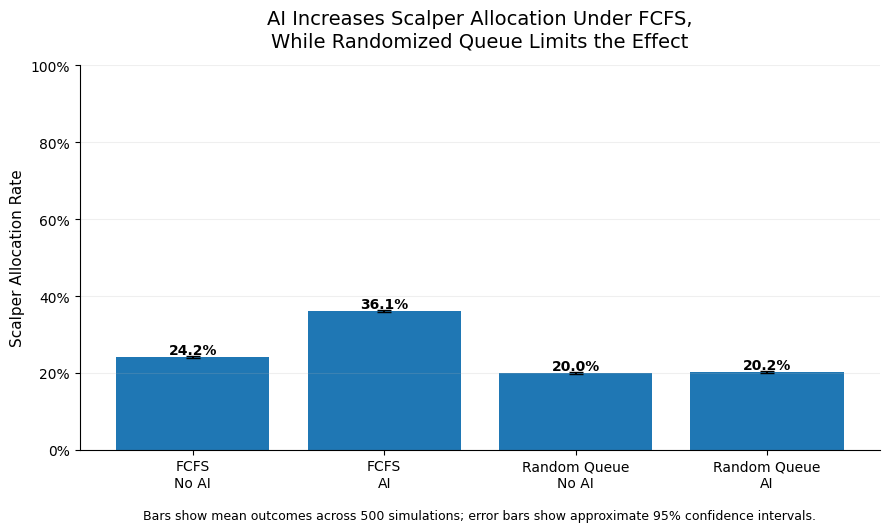

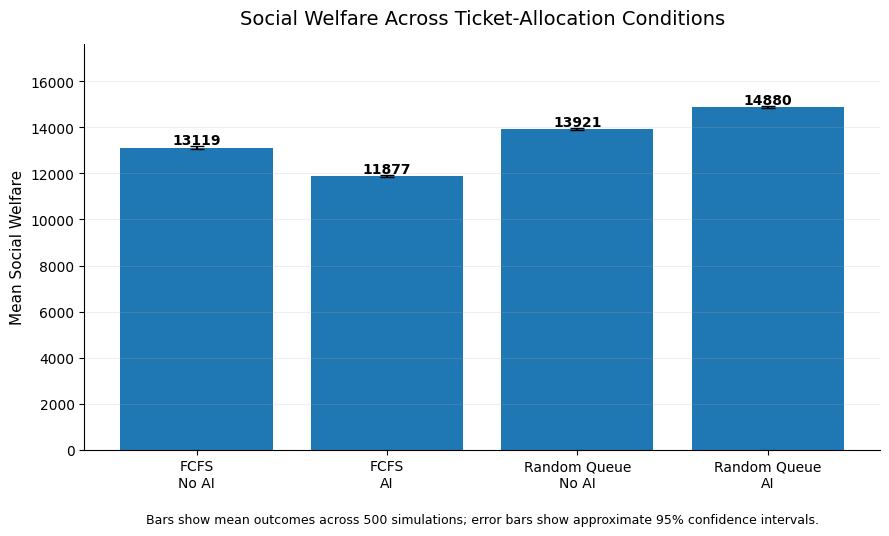

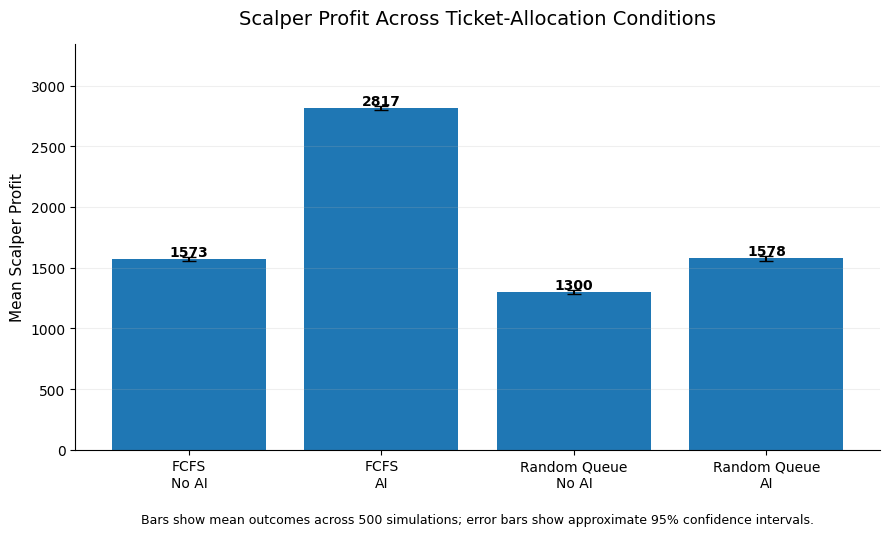


Fresh-run reproducibility record
Seed: 2026
Number of simulations per condition: 500

Conditions tested:
1. FCFS / No AI
2. FCFS / AI
3. Randomized Queue / No AI
4. Randomized Queue / AI

Saved outputs:
- simulation_results.csv
- summary_results.csv
- ai_effect_comparison.csv
- figures/figure1_genuine_fan_allocation.png
- figures/figure2_scalper_allocation.png
- figures/figure3_social_welfare.png
- figures/figure4_scalper_profit.png

Evidence boundary: These are synthetic simulation results under stipulated parameters. They demonstrate how the model behaves under its assumptions and are not estimates of real-world ticket markets.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import os

# ============================================================
# AI-Assisted Ticket Allocation Simulation
# COMSCI/ECON 206 PS2
#
# Research question:
# How does AI-assisted ticket buying change the allocation
# of limited concert tickets between genuine fans and scalpers,
# and can a randomized queue reduce this effect?
#
# 2 x 2 design:
#   1. FCFS / No AI
#   2. FCFS / AI
#   3. Randomized Queue / No AI
#   4. Randomized Queue / AI
# ============================================================


# ============================================================
# 1. Reproducibility and global parameters
# ============================================================

RANDOM_SEED = 2026

N_FANS = 200
N_SCALPERS = 50
N_TICKETS = 100

N_SIMULATIONS = 500

TICKET_PRICE = 100
RESALE_PRICE = 180

# Participation costs
FAN_NO_AI_COST = 12
FAN_AI_COST = 3

SCALPER_NO_AI_COST = 15
SCALPER_AI_COST = 2

# Genuine fans' private attendance values
FAN_VALUE_LOW = 120
FAN_VALUE_HIGH = 260

# Scalpers do not value attending the concert itself.
SCALPER_ATTENDANCE_VALUE = 0


# ============================================================
# 2. Generate participants
# ============================================================

def generate_participants(rng):
    """
    Generate genuine fans and scalpers.

    Genuine fans:
    - have private attendance values
    - differ in purchasing speed

    Scalpers:
    - primarily value resale opportunities
    - may benefit strongly from AI-assisted automation
    """

    fan_values = rng.uniform(
        FAN_VALUE_LOW,
        FAN_VALUE_HIGH,
        N_FANS
    )

    fans = pd.DataFrame({
        "participant_id": [f"fan_{i}" for i in range(N_FANS)],
        "type": "fan",
        "value": fan_values,
        "base_speed": rng.normal(
            loc=0.0,
            scale=1.0,
            size=N_FANS
        )
    })

    scalpers = pd.DataFrame({
        "participant_id": [
            f"scalper_{i}"
            for i in range(N_SCALPERS)
        ],
        "type": "scalper",
        "value": SCALPER_ATTENDANCE_VALUE,
        "base_speed": rng.normal(
            loc=0.4,
            scale=1.0,
            size=N_SCALPERS
        )
    })

    participants = pd.concat(
        [fans, scalpers],
        ignore_index=True
    )

    return participants


# ============================================================
# 3. Participation decision
# ============================================================

def apply_participation_decision(df, ai_enabled):
    """
    Participants enter when expected benefit exceeds
    ticket price plus participation cost.

    AI lowers the cost of participation.
    """

    df = df.copy()

    if ai_enabled:
        fan_cost = FAN_AI_COST
        scalper_cost = SCALPER_AI_COST
    else:
        fan_cost = FAN_NO_AI_COST
        scalper_cost = SCALPER_NO_AI_COST

    df["participation_cost"] = np.where(
        df["type"] == "fan",
        fan_cost,
        scalper_cost
    )

    fan_surplus = (
        df["value"]
        - TICKET_PRICE
        - df["participation_cost"]
    )

    scalper_surplus = (
        RESALE_PRICE
        - TICKET_PRICE
        - df["participation_cost"]
    )

    df["participates"] = np.where(
        df["type"] == "fan",
        fan_surplus > 0,
        scalper_surplus > 0
    )

    return df[df["participates"]].copy()


# ============================================================
# 4. Allocation mechanism: FCFS
# ============================================================

def allocate_fcfs(df, ai_enabled, rng):
    """
    First-Come, First-Served.

    Higher effective speed means earlier completion.

    AI provides a larger speed advantage to scalpers because
    automated tools may allow them to submit requests faster
    and at greater scale.
    """

    df = df.copy()

    random_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=len(df)
    )

    if ai_enabled:
        ai_bonus = np.where(
            df["type"] == "scalper",
            1.5,
            0.4
        )
    else:
        ai_bonus = np.zeros(len(df))

    df["effective_speed"] = (
        df["base_speed"]
        + ai_bonus
        + random_noise
    )

    df = df.sort_values(
        by="effective_speed",
        ascending=False
    )

    winners = df.head(N_TICKETS).copy()

    return winners


# ============================================================
# 5. Allocation mechanism: Randomized Queue
# ============================================================

def allocate_random_queue(df, rng):
    """
    Randomized Queue.

    Participants entering during the allowed purchase window
    receive a random priority.

    Raw completion speed does not directly determine priority.
    """

    df = df.copy()

    df["random_priority"] = rng.random(len(df))

    df = df.sort_values(
        by="random_priority",
        ascending=True
    )

    winners = df.head(N_TICKETS).copy()

    return winners


# ============================================================
# 6. Outcome metrics
# ============================================================

def calculate_metrics(winners):
    """
    Main project metrics:

    1. Genuine-fan allocation rate
    2. Scalper allocation rate
    3. Social welfare
    4. Scalper profit

    Welfare is kept separate from scalper resale profit.
    """

    n_allocated = len(winners)

    if n_allocated == 0:
        return {
            "genuine_fan_allocation_rate": np.nan,
            "scalper_allocation_rate": np.nan,
            "social_welfare": 0,
            "scalper_profit": 0
        }

    fan_winners = winners[
        winners["type"] == "fan"
    ]

    scalper_winners = winners[
        winners["type"] == "scalper"
    ]

    genuine_fan_allocation_rate = (
        len(fan_winners) / n_allocated
    )

    scalper_allocation_rate = (
        len(scalper_winners) / n_allocated
    )

    # Social welfare:
    # value generated by genuine attendance
    # minus participation costs paid by all winners.
    fan_attendance_value = fan_winners["value"].sum()

    total_participation_cost = (
        winners["participation_cost"].sum()
    )

    social_welfare = (
        fan_attendance_value
        - total_participation_cost
    )

    # Scalper private profit is reported separately.
    scalper_profit = (
        RESALE_PRICE
        - TICKET_PRICE
        - scalper_winners["participation_cost"]
    ).sum()

    return {
        "genuine_fan_allocation_rate":
            genuine_fan_allocation_rate,

        "scalper_allocation_rate":
            scalper_allocation_rate,

        "social_welfare":
            social_welfare,

        "scalper_profit":
            scalper_profit
    }


# ============================================================
# 7. Run one market condition
# ============================================================

def run_single_condition(
    mechanism,
    ai_enabled,
    simulation_seed
):
    """
    Run one simulated ticket market.
    """

    local_rng = np.random.default_rng(
        simulation_seed
    )

    participants = generate_participants(
        local_rng
    )

    participants = apply_participation_decision(
        participants,
        ai_enabled=ai_enabled
    )

    if mechanism == "FCFS":

        winners = allocate_fcfs(
            participants,
            ai_enabled=ai_enabled,
            rng=local_rng
        )

    elif mechanism == "Randomized Queue":

        winners = allocate_random_queue(
            participants,
            rng=local_rng
        )

    else:

        raise ValueError(
            "Mechanism must be 'FCFS' "
            "or 'Randomized Queue'."
        )

    metrics = calculate_metrics(
        winners
    )

    metrics["mechanism"] = mechanism

    metrics["ai"] = (
        "AI"
        if ai_enabled
        else "No AI"
    )

    return metrics


# ============================================================
# 8. Run repeated simulations
# ============================================================

conditions = [
    ("FCFS", False),
    ("FCFS", True),
    ("Randomized Queue", False),
    ("Randomized Queue", True)
]

all_results = []

for simulation in range(N_SIMULATIONS):

    base_seed = (
        RANDOM_SEED
        + simulation * 10
    )

    for condition_index, (
        mechanism,
        ai_enabled
    ) in enumerate(conditions):

        result = run_single_condition(
            mechanism=mechanism,
            ai_enabled=ai_enabled,
            simulation_seed=(
                base_seed
                + condition_index
            )
        )

        result["simulation"] = simulation

        all_results.append(result)

results_df = pd.DataFrame(
    all_results
)


# ============================================================
# 9. Mean outcome table
# ============================================================

metrics = [
    "genuine_fan_allocation_rate",
    "scalper_allocation_rate",
    "social_welfare",
    "scalper_profit"
]

summary = (
    results_df
    .groupby(
        ["mechanism", "ai"]
    )[metrics]
    .mean()
    .reset_index()
)

print()
print("=" * 64)
print("AI-Assisted Ticket Allocation Simulation")
print("=" * 64)

print(f"Random seed: {RANDOM_SEED}")
print(
    f"Simulations per condition: "
    f"{N_SIMULATIONS}"
)
print(f"Genuine fans: {N_FANS}")
print(f"Scalpers: {N_SCALPERS}")
print(f"Tickets: {N_TICKETS}")

print()
print("Mean outcomes:")
print(
    summary
    .round(3)
    .to_string(index=False)
)


# ============================================================
# 10. Confidence intervals
# ============================================================

def calculate_summary_with_ci(
    data,
    metric
):
    """
    Calculate mean and approximate 95% confidence interval.
    """

    grouped = (
        data
        .groupby(
            ["mechanism", "ai"]
        )[metric]
        .agg(
            ["mean", "std", "count"]
        )
        .reset_index()
    )

    grouped["se"] = (
        grouped["std"]
        / np.sqrt(
            grouped["count"]
        )
    )

    grouped["ci95"] = (
        1.96
        * grouped["se"]
    )

    return grouped


# ============================================================
# 11. Effect of AI table
# ============================================================

fan_pivot = summary.pivot(
    index="mechanism",
    columns="ai",
    values="genuine_fan_allocation_rate"
)

scalper_pivot = summary.pivot(
    index="mechanism",
    columns="ai",
    values="scalper_allocation_rate"
)

comparison_rows = []

for mechanism in [
    "FCFS",
    "Randomized Queue"
]:

    fan_change = (
        fan_pivot.loc[
            mechanism,
            "AI"
        ]
        -
        fan_pivot.loc[
            mechanism,
            "No AI"
        ]
    )

    scalper_change = (
        scalper_pivot.loc[
            mechanism,
            "AI"
        ]
        -
        scalper_pivot.loc[
            mechanism,
            "No AI"
        ]
    )

    comparison_rows.append({
        "mechanism":
            mechanism,

        "change_in_fan_allocation_with_AI":
            fan_change,

        "change_in_scalper_allocation_with_AI":
            scalper_change
    })

comparison_df = pd.DataFrame(
    comparison_rows
)

print()
print("=" * 64)
print("Effect of AI within each mechanism")
print("=" * 64)

print(
    comparison_df
    .round(3)
    .to_string(index=False)
)


# ============================================================
# 12. Main interpretation
# ============================================================

def get_value(
    mechanism,
    ai,
    metric
):

    return summary[
        (summary["mechanism"] == mechanism)
        &
        (summary["ai"] == ai)
    ][metric].iloc[0]


fcfs_no_ai_scalper = get_value(
    "FCFS",
    "No AI",
    "scalper_allocation_rate"
)

fcfs_ai_scalper = get_value(
    "FCFS",
    "AI",
    "scalper_allocation_rate"
)

queue_no_ai_scalper = get_value(
    "Randomized Queue",
    "No AI",
    "scalper_allocation_rate"
)

queue_ai_scalper = get_value(
    "Randomized Queue",
    "AI",
    "scalper_allocation_rate"
)

print()
print("=" * 64)
print("Main interpretation")
print("=" * 64)

print(
    "Under FCFS, the scalper allocation rate changes "
    f"from {fcfs_no_ai_scalper:.1%} without AI "
    f"to {fcfs_ai_scalper:.1%} with AI."
)

print(
    "Under Randomized Queue, the scalper allocation "
    f"rate changes from {queue_no_ai_scalper:.1%} "
    f"without AI to {queue_ai_scalper:.1%} with AI."
)

fcfs_change = (
    fcfs_ai_scalper
    - fcfs_no_ai_scalper
)

queue_change = (
    queue_ai_scalper
    - queue_no_ai_scalper
)

print(
    "AI changes the scalper allocation rate by "
    f"{fcfs_change:+.1%} under FCFS and "
    f"{queue_change:+.1%} under Randomized Queue."
)

if queue_ai_scalper < fcfs_ai_scalper:

    print(
        "Under the stated assumptions, Randomized Queue "
        "substantially reduces the scalper allocation rate "
        "relative to AI-assisted FCFS."
    )

else:

    print(
        "Under the stated assumptions, Randomized Queue "
        "does not reduce the scalper allocation rate "
        "relative to AI-assisted FCFS."
    )


# ============================================================
# 13. Prepare labels for figures
# ============================================================

condition_order = [
    ("FCFS", "No AI"),
    ("FCFS", "AI"),
    ("Randomized Queue", "No AI"),
    ("Randomized Queue", "AI")
]

condition_labels = [
    "FCFS\nNo AI",
    "FCFS\nAI",
    "Random Queue\nNo AI",
    "Random Queue\nAI"
]

os.makedirs(
    "figures",
    exist_ok=True
)


# ============================================================
# 14. Helper function for publication-style figures
# ============================================================

def make_bar_figure(
    metric,
    ylabel,
    title,
    filename,
    percent=False,
    decimals=1
):

    stats = calculate_summary_with_ci(
        results_df,
        metric
    )

    means = []
    errors = []

    for mechanism, ai in condition_order:

        row = stats[
            (stats["mechanism"] == mechanism)
            &
            (stats["ai"] == ai)
        ].iloc[0]

        means.append(
            row["mean"]
        )

        errors.append(
            row["ci95"]
        )

    x = np.arange(
        len(condition_labels)
    )

    fig, ax = plt.subplots(
        figsize=(9, 5.5)
    )

    bars = ax.bar(
        x,
        means,
        yerr=errors,
        capsize=5
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        condition_labels,
        fontsize=10
    )

    ax.set_ylabel(
        ylabel,
        fontsize=11
    )

    ax.set_title(
        title,
        fontsize=14,
        pad=14
    )

    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )

    ax.grid(
        axis="y",
        alpha=0.2
    )

    if percent:

        ax.set_ylim(
            0,
            1
        )

        ax.yaxis.set_major_formatter(
            PercentFormatter(
                1.0
            )
        )

    else:

        maximum = max(
            np.array(means)
            +
            np.array(errors)
        )

        ax.set_ylim(
            0,
            maximum * 1.18
        )

    for bar, value in zip(
        bars,
        means
    ):

        if percent:

            label = (
                f"{value:.1%}"
            )

        else:

            label = (
                f"{value:.{decimals}f}"
            )

        ax.text(
            bar.get_x()
            +
            bar.get_width() / 2,

            bar.get_height(),

            label,

            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.text(
        0.5,
        -0.18,
        (
            "Bars show mean outcomes across "
            f"{N_SIMULATIONS} simulations; "
            "error bars show approximate 95% confidence intervals."
        ),
        transform=ax.transAxes,
        ha="center",
        fontsize=9
    )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 15. Figure 1: Genuine-fan allocation
# ============================================================

make_bar_figure(
    metric="genuine_fan_allocation_rate",
    ylabel="Genuine-Fan Allocation Rate",
    title=(
        "AI Reduces Genuine-Fan Access Under FCFS,\n"
        "But Not Under a Randomized Queue"
    ),
    filename=(
        "figures/"
        "figure1_genuine_fan_allocation.png"
    ),
    percent=True
)


# ============================================================
# 16. Figure 2: Scalper allocation
# ============================================================

make_bar_figure(
    metric="scalper_allocation_rate",
    ylabel="Scalper Allocation Rate",
    title=(
        "AI Increases Scalper Allocation Under FCFS,\n"
        "While Randomized Queue Limits the Effect"
    ),
    filename=(
        "figures/"
        "figure2_scalper_allocation.png"
    ),
    percent=True
)


# ============================================================
# 17. Figure 3: Social welfare
# ============================================================

make_bar_figure(
    metric="social_welfare",
    ylabel="Mean Social Welfare",
    title=(
        "Social Welfare Across Ticket-Allocation Conditions"
    ),
    filename=(
        "figures/"
        "figure3_social_welfare.png"
    ),
    percent=False,
    decimals=0
)


# ============================================================
# 18. Figure 4: Scalper profit
# ============================================================

make_bar_figure(
    metric="scalper_profit",
    ylabel="Mean Scalper Profit",
    title=(
        "Scalper Profit Across Ticket-Allocation Conditions"
    ),
    filename=(
        "figures/"
        "figure4_scalper_profit.png"
    ),
    percent=False,
    decimals=0
)


# ============================================================
# 19. Save result tables
# ============================================================

results_df.to_csv(
    "simulation_results.csv",
    index=False
)

summary.to_csv(
    "summary_results.csv",
    index=False
)

comparison_df.to_csv(
    "ai_effect_comparison.csv",
    index=False
)


# ============================================================
# 20. Fresh-run reproducibility record
# ============================================================

print()
print("=" * 64)
print("Fresh-run reproducibility record")
print("=" * 64)

print(
    f"Seed: {RANDOM_SEED}"
)

print(
    f"Number of simulations per condition: "
    f"{N_SIMULATIONS}"
)

print()

print(
    "Conditions tested:"
)

print(
    "1. FCFS / No AI"
)

print(
    "2. FCFS / AI"
)

print(
    "3. Randomized Queue / No AI"
)

print(
    "4. Randomized Queue / AI"
)

print()

print(
    "Saved outputs:"
)

print(
    "- simulation_results.csv"
)

print(
    "- summary_results.csv"
)

print(
    "- ai_effect_comparison.csv"
)

print(
    "- figures/figure1_genuine_fan_allocation.png"
)

print(
    "- figures/figure2_scalper_allocation.png"
)

print(
    "- figures/figure3_social_welfare.png"
)

print(
    "- figures/figure4_scalper_profit.png"
)

print()

print(
    "Evidence boundary: These are synthetic simulation results "
    "under stipulated parameters. They demonstrate how the "
    "model behaves under its assumptions and are not estimates "
    "of real-world ticket markets."
)